In [5]:
from plotly import graph_objects as go
from freqtrade.plot.plotting import  generate_candlestick_graph
from scipy.signal import argrelextrema
import pandas as pd
import numpy as np
import os
from pathlib import Path
import numpy as np
from freqtrade.data.history import load_pair_history
from freqtrade.enums import CandleType
from freqtrade.configuration import Configuration
from matplotlib import pyplot as plt
from sklearn.cluster import HDBSCAN

In [6]:
project_root = "somedir/freqtrade"
i=0
try:
    os.chdirdir(project_root)
    assert Path('docker-compose.yml').is_file()
except:
    while i<4 and (not Path('docker-compose.yml').is_file()):
        os.chdir(Path(Path.cwd(), '../'))
        i+=1
    project_root = Path.cwd()
print(Path.cwd())

/root/trade


In [7]:
# config = Configuration.from_files([])
config = Configuration.from_files(["user_data/rb_config.json"])

config["timeframe"] = "15m"
config["strategy"] = "ReactionBreakStrategy"
data_location = config["datadir"]
pair = "CHR/USDT:USDT"

In [ ]:
!freqtrade download-data -t 15m --pairs CHR/USDT:USDT -c user_data/rb_config.json

In [9]:
candles = load_pair_history(
    datadir=data_location,
    timeframe=config["timeframe"],
    pair=pair,
    data_format = "feather",
    candle_type=CandleType.FUTURES,
)

# candles.close.value_counts().sort_values(ascending=False)

print(f"Loaded {len(candles)} rows of data for {pair} from {data_location}")

Loaded 6023 rows of data for CHR/USDT:USDT from /root/trade/user_data/data/bybit


In [42]:
window = 8
df = candles.copy()
df = df.set_index('date', drop=False)
df = df['2024-02-20':'2024-02-24']
df['min_values'] = df.iloc[argrelextrema(df.close.values, np.less_equal,order=window)[0]]['close']
df['max_values'] = df.iloc[argrelextrema(df.close.values, np.greater_equal,order=window)[0]]['close']
df['extrema'] = df['max_values'].fillna(df['min_values'])
X = np.array(df['extrema'].dropna().values.tolist()).reshape(-1, 1)

In [44]:
hdb = HDBSCAN()
hdb.fit(X)
df_ = pd.DataFrame({'values':df['extrema'].dropna().values ,'labels':hdb.labels_, 'probabilities':hdb.probabilities_})

In [56]:
# label = 0
prob = 0.5
fig = generate_candlestick_graph(pair=pair, data=df)
for label in [0,1]:
    Max = df_[(df_.labels == label) & (df_.probabilities > prob)]['values'].max()
    Min = df_[(df_.labels == label & (df_.probabilities > prob))]['values'].min()
    fig.add_hline(y=Max, line_width=1, line_dash="dash")
    fig.add_hline(y=Min, line_width=1, line_dash="dash")
fig.show()

In [36]:
df_.probabilities.unique()

array([0.        , 1.        , 0.95652174, 0.65789474, 0.80645161,
       0.73333333, 0.92592593, 0.70967742, 0.84615385])

In [9]:
low_limit, high_limit = -1e-3, +1e-3
bins_width = 0.003
window = 8
threshold = 5
df = candles.copy()
df = df.set_index('date', drop=False)
df = df['2024-02-20':'2024-02-29']
df['min_values'] = df.iloc[argrelextrema(df.low.values, np.less_equal,order=window)[0]]['low'] + low_limit
df['max_values'] = df.iloc[argrelextrema(df.high.values, np.greater_equal,order=window)[0]]['high'] + high_limit
df['extrema'] = df['max_values'].fillna(df['min_values'])
bins = int((df.close.max() - df.close.min()) / bins_width) + 1
array = df['extrema'].value_counts(bins = bins)
upper_values = array[array >= threshold].index.left.values
lower_values = array[array >= threshold].index.right.values
fig = go.Figure()
graph = generate_candlestick_graph(
    pair=pair,
    data=df,
    # trades=trades_red,
    # indicators1=['sma20', 'ema50', 'ema55'],
    # indicators2=['rsi', 'macd', 'macdsignal', 'macdhist']
)
for value in list(upper_values) + list(lower_values):
    graph.add_hline(y=value, line_width=1, line_dash="dash", line_color="green")
graph.add_trace(go.Scatter(x=df['date'],y=df['extrema'], mode = 'markers', marker_color='orange'))
graph.update_layout(autosize=True, height=700, xaxis=dict(rangeslider=dict(visible=False)))

In [ ]:
from sklearn import preprocessing
import numpy as np
X_train = np.array([[ 1., -1.,  2.],
                    [ 2.,  0.,  0.],
                    [ 0.,  1., -1.]])
scaler = preprocessing.StandardScaler().fit(X_train)
scaler

scaler.mean_

scaler.scale_

X_scaled = scaler.transform(X_train)
X_scaled

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from plotly import graph_objects as go
import numpy as np

In [3]:
scaler = StandardScaler()
features, true_labels = make_moons(
    n_samples=250, noise=0.05, random_state=42
)
scaled_features = scaler.fit_transform(features)

In [35]:
dbscan = DBSCAN(eps=0.3)
dbscan.fit(scaled_features)

DBSCAN(eps=0.3)

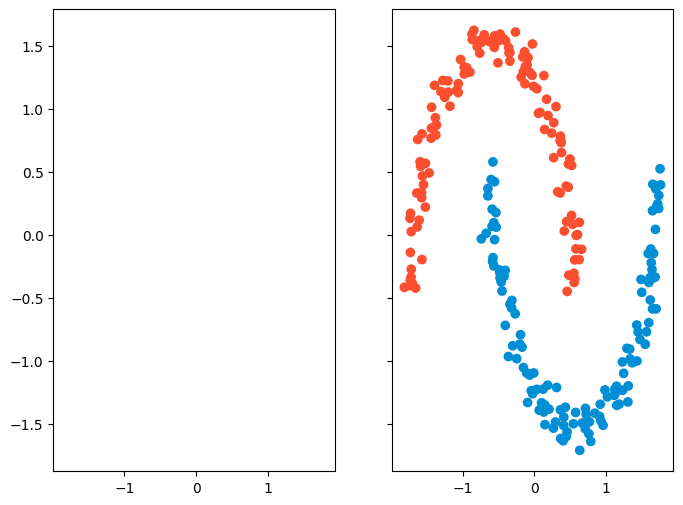

In [36]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(8, 6), sharex=True, sharey=True
)
fte_colors = {
    0: "#008fd5",
    1: "#fc4f30",
}
db_colors = [fte_colors[label] for label in dbscan.labels_]
ax2.scatter(scaled_features[:, 0], scaled_features[:, 1], c=db_colors)
plt.show()

In [37]:
dbscan.labels_

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1])

In [ ]:
from freqtrade.resolvers import StrategyResolver
from freqtrade.data.dataprovider import DataProvider
strategy = StrategyResolver.load_strategy(config)
strategy.dp = DataProvider(config, None, None)
strategy.ft_bot_start()
df = strategy.analyze_ticker(candles, {'pair': pair})
data = df.set_index('date', drop=False)
print(f"Generated {df['enter_long'].sum()} entry signals")

In [ ]:
from freqtrade.data.btanalysis import load_backtest_data, load_backtest_stats

# if backtest_dir points to a directory, it'll automatically load the last backtest file.
backtest_dir = config["user_data_dir"] / "backtest_results"
# backtest_dir can also point to a specific file 
# backtest_dir = config["user_data_dir"] / "backtest_results/backtest-result-2020-07-01_20-04-22.json"

## Backtest

In [ ]:
# You can get the full backtest statistics by using the following command.
# This contains all information used to generate the backtest result.
stats = load_backtest_stats(backtest_dir)

strategy = 'SampleStrategy'
# All statistics are available per strategy, so if `--strategy-list` was used during backtest, this will be reflected here as well.
# Example usages:
print(stats['strategy'][strategy]['results_per_pair'])
# Get pairlist used for this backtest
print(stats['strategy'][strategy]['pairlist'])
# Get market change (average change of all pairs from start to end of the backtest period)
print(stats['strategy'][strategy]['market_change'])
# Maximum drawdown ()
print(stats['strategy'][strategy]['max_drawdown'])
# Maximum drawdown start and end
print(stats['strategy'][strategy]['drawdown_start'])
print(stats['strategy'][strategy]['drawdown_end'])


# Get strategy comparison (only relevant if multiple strategies were compared)
print(stats['strategy_comparison'])


In [ ]:
# Load backtested trades as dataframe
trades = load_backtest_data(backtest_dir)

# Show value-counts per pair
trades.groupby("pair")["exit_reason"].value_counts()

## Plotting daily profit / equity line

In [ ]:
# Plotting equity line (starting with 0 on day 1 and adding daily profit for each backtested day)

from freqtrade.configuration import Configuration
from freqtrade.data.btanalysis import load_backtest_stats
import plotly.express as px
import pandas as pd

# strategy = 'SampleStrategy'
# config = Configuration.from_files(["user_data/config.json"])
# backtest_dir = config["user_data_dir"] / "backtest_results"

stats = load_backtest_stats(backtest_dir)
strategy_stats = stats['strategy'][strategy]

df = pd.DataFrame(columns=['dates','equity'], data=strategy_stats['daily_profit'])
df['equity_daily'] = df['equity'].cumsum()

fig = px.line(df, x="dates", y="equity_daily")
fig.show()


### Load live trading results into a pandas dataframe

In case you did already some trading and want to analyze your performance

In [4]:
from freqtrade.data.btanalysis import load_trades_from_db

# Fetch trades from database
trades = load_trades_from_db("sqlite:///user_data/ReactionBreakStrategy_dry.sqlite")

# Display results
trades.groupby("pair")["exit_reason"].value_counts()

pair            exit_reason       
CHR/USDT:USDT   trailing_stop_loss    15
                stop_loss              1
DUSK/USDT:USDT  trailing_stop_loss     1
MINA/USDT:USDT  trailing_stop_loss    19
                stop_loss              1
RNDR/USDT:USDT  trailing_stop_loss    19
                stop_loss              1
Name: count, dtype: int64

In [5]:
# trades_red = trades.loc[trades['pair'] == pair]

## Analyze the loaded trades for trade parallelism
This can be useful to find the best `max_open_trades` parameter, when used with backtesting in conjunction with `--disable-max-market-positions`.

`analyze_trade_parallelism()` returns a timeseries dataframe with an "open_trades" column, specifying the number of open trades for each candle.

In [ ]:
from freqtrade.data.btanalysis import analyze_trade_parallelism

# Analyze the above
parallel_trades = analyze_trade_parallelism(trades, '5m')

parallel_trades.plot()

## Plot results

Freqtrade offers interactive plotting capabilities based on plotly.

In [ ]:
from freqtrade.plot.plotting import  generate_candlestick_graph
# Limit graph period to keep plotly quick and reactive

# Filter trades to one pair
trades_red = trades.loc[trades['pair'] == pair]

data_red = data['2019-06-01':'2019-06-10']
# Generate candlestick graph
graph = generate_candlestick_graph(pair=pair,
                                   data=data_red,
                                   trades=trades_red,
                                   indicators1=['sma20', 'ema50', 'ema55'],
                                   indicators2=['rsi', 'macd', 'macdsignal', 'macdhist']
                                  )
graph.show()

In [ ]:
# Show graph inline
graph.show()

# Render graph in a separate window
# graph.show(renderer="browser")


## Plot average profit per trade as distribution graph

In [ ]:
import plotly.figure_factory as ff

hist_data = [trades.profit_ratio]
group_labels = ['profit_ratio']  # name of the dataset

fig = ff.create_distplot(hist_data, group_labels, bin_size=0.01)
fig.show()


In [6]:
from freqtrade.data.btanalysis import load_trades_from_db
trades = load_trades_from_db("sqlite:///user_data/ReactionBreakStrategy_dry.sqlite")
trades.profit_ratio.sum()

-0.027612510795092537

In [ ]:
from scipy.signal import argrelextrema, find_peaks
import numpy as np
import pandas as pd
from plotly import graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
peaks = find_peaks(candles.close)
candles['min'] = candles.iloc[argrelextrema(candles.close.values, np.less_equal,order=5)[0]]['close']
candles['peaks'] = candles.iloc[find_peaks(candles.close,prominence=10)[0]]['close']

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=candles['date'],y=candles['close']))
fig.add_trace(go.Scatter(x=candles['date'],y=candles['peaks'],mode = 'markers'))
fig.add_hline(y=1.2719, line_width=1, line_dash="dash", line_color="green")
fig.add_hline(y=1.2308, line_width=1, line_dash="dash", line_color="green")
fig.show()

# fig = make_subplots(rows=2, cols=1)#, shared_xaxes=True)#, row_width=[0.2, 0.8])
# fig.add_trace(go.Scatter(x=candles['date'], y=candles['close'], name='Close price'), row=1, col=1)
# fig.add_trace(go.Scatter(x=candles['date'], y=candles['extrema'], name='Extrema', mode = 'markers'), row=1, col=1)
# fig.update_layout(autosize=True, height=700, xaxis=dict(rangeslider=dict(visible=False)))
# fig.show()

In [ ]:
import numpy as np
from sklearn.cluster import HDBSCAN

In [49]:
low_limit, high_limit = -1e-3, +1e-3
bins_width = 0.001
window = 8
threshold = 3
df = candles.copy()
df = df.set_index('date', drop=False)
df = df['2024-02-20':'2024-02-24']
df['min_values'] = df.iloc[argrelextrema(df.low.values, np.less_equal,order=window)[0]]['low'] + low_limit
df['max_values'] = df.iloc[argrelextrema(df.high.values, np.greater_equal,order=window)[0]]['high'] + high_limit
df['extrema'] = df['max_values'].fillna(df['min_values'])
df['new'] = 1
X = np.array(df[['new','extrema']].dropna().values.tolist())

In [ ]:
hdb = HDBSCAN()
hdb.fit(X)

In [90]:
df_ = pd.DataFrame({'values':df['extrema'].dropna().values ,'labels':hdb.labels_, 'probabilities':hdb.probabilities_})
fig = go.Figure()
fig.add_trace(go.Scatter(x=candles['date'],y=candles['close']))
for lable in [1,0]:
    Max = df_[(df_.labels == lable)]['values'].max()
    Min = df_[(df_.labels == lable)]['values'].min()
    fig.add_hline(y=Max, line_width=1, line_dash="dash")
    fig.add_hline(y=Min, line_width=1, line_dash="dash")
fig.show()